# 如果我的数据集不在 Hub 上怎么办？

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [ ]:
!pip install datasets evaluate transformers[sentencepiece]

##使用本地和远程数据集

🤗 Datasets 提供了加载本地和远程数据集的方法。它支持几种常见的数据格式。

如表所示，对于每种数据格式，我们只需要在 `load_dataset()` 函数中指定数据的类型，并使用 data_files 指定一个或多个文件的路径的参数。

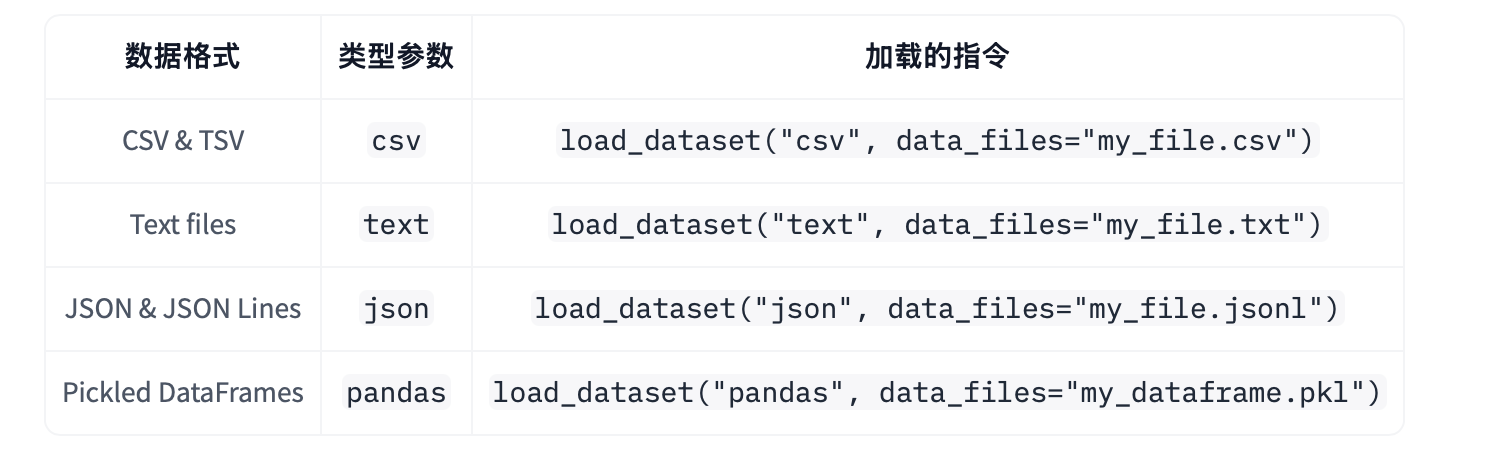

###加载本地数据集

In [ ]:
!wget https://github.com/crux82/squad-it/raw/master/SQuAD_it-train.json.gz
!wget https://github.com/crux82/squad-it/raw/master/SQuAD_it-test.json.gz

In [ ]:
!gzip -dkv SQuAD_it-*.json.gz

我们使用 load_dataset() 函数来加载 JSON 文件时，我们需要知道我们是在处理普通的 JSON（类似于嵌套字典）还是 JSON Lines（每一行都是一个 JSON）。像许多问答数据集一样，SQuAD-it 使用的是**嵌套字典**，所有文本都存储在 data 字段中。这意味着我们可以通过**使用参数 `field` 来加载数据集**，如下所示：

In [ ]:
from datasets import load_dataset

squad_it_dataset = load_dataset("json", data_files="SQuAD_it-train.json", field="data")

默认情况下，加载本地文件会创建一个带有 train 标签的 DatasetDict 对象。我们可以在这里查看一下 squad_it_dataset 对象：

In [ ]:
squad_it_dataset

DatasetDict({
    train: Dataset({
        features: ['title', 'paragraphs'],
        num_rows: 442
    })
})

输出了与训练集的行数和列名。我们可以使用 train 标签来查看数据集中的一个示例，如下所示：

In [ ]:
squad_it_dataset["train"][0]

{
    "title": "Terremoto del Sichuan del 2008",
    "paragraphs": [
        {
            "context": "Il terremoto del Sichuan del 2008 o il terremoto...",
            "qas": [
                {
                    "answers": [{"answer_start": 29, "text": "2008"}],
                    "id": "56cdca7862d2951400fa6826",
                    "question": "In quale anno si è verificato il terremoto nel Sichuan?",
                },
                ...
            ],
        },
        ...
    ],
}

很好，我们已经加载了我们的第一个本地数据集！但是，也仅仅加载了训练集，我们**真正想要的是包含 train 和 test 的 DatasetDict 对象**。这样的话就可以使用 `Dataset.map()` 函数**同时处理训练集和测试集**。为此，我们向 `data_files` 参数输入一个字典，**将数据集的标签名映射到相关联的文件**：

In [ ]:
data_files = {"train": "SQuAD_it-train.json", "test": "SQuAD_it-test.json"}
squad_it_dataset = load_dataset("json", data_files=data_files, field="data")
squad_it_dataset

DatasetDict({
    train: Dataset({
        features: ['title', 'paragraphs'],
        num_rows: 442
    })
    test: Dataset({
        features: ['title', 'paragraphs'],
        num_rows: 48
    })
})

这正是我们想要的。现在，我们可以使用各种预处理技术来清洗数据、tokenize 评论等等。

🤗 Datasets 实际上支持自动解压输入文件，所以我们可以跳过使用 gzip ，直接将 data_files 参数设置为压缩文件：

In [ ]:
data_files = {"train": "SQuAD_it-train.json.gz", "test": "SQuAD_it-test.json.gz"}
squad_it_dataset = load_dataset("json", data_files=data_files, field="data")

###加载远程数据集

如果你在公司担任数据研究员或编程员，那么你要分析的数据集很有可能存储在某个远程服务器上。幸运的是，加载远程文件就像加载本地文件一样简单！我们只需要将 `load_dataset()` 的 `data_files` 参数指向存储远程文件的一个或多个 URL。例如，对于托管在 GitHub 上的 SQuAD-it 数据集，我们可以将 data_files 设置为指向 SQuAD_it-*.json.gz 的网址，如下所示：

In [ ]:
url = "https://github.com/crux82/squad-it/raw/master/"
data_files = {
    "train": url + "SQuAD_it-train.json.gz",
    "test": url + "SQuAD_it-test.json.gz",
}
squad_it_dataset = load_dataset("json", data_files=data_files, field="data")